# KV Cache Compression on LongBench with Qwen2.5-1.5B  
## Baseline vs Scissorhands-style vs AdaKV-style (no FlashAttention)

This notebook is designed for **Google Colab / A100** and gives you an end-to-end pipeline for:

- loading **Qwen/Qwen2.5-1.5B-Instruct**
- evaluating on a **LongBench** subset
- running three methods:
  - **Baseline**
  - **Scissorhands-style KV compression**
  - **AdaKV-style adaptive per-layer budget KV compression**
- saving predictions
- computing task scores
- plotting the final comparison

## Important note
This notebook implements **lightweight, operational Hugging Face versions** of:

- **Scissorhands-style persistent-token retention**
- **AdaKV-style adaptive per-layer budget allocation**

These are intended for a **course project benchmark without FlashAttention**. They are **not official repo reproductions** of the papers, but they preserve the core ideas for a controlled comparative experiment.


## 1. Install dependencies

In [1]:
!pip -q install transformers accelerate datasets sentencepiece rouge-score matplotlib tqdm "pandas==2.2.2"

  Preparing metadata (setup.py) ... done


In [2]:
!pip -q install --force-reinstall "pandas==2.2.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 40.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


## 2. Imports and global config

In [2]:
import os
import re
import gc
import math
import json
import time
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from rouge_score import rouge_scorer
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
!nvidia-smi


device: cuda
gpu: NVIDIA A100-SXM4-40GB
Mon Mar  9 01:56:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             46W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-------

## 3. Experiment settings

In [3]:
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

# Final LongBench subset (good coverage of tasks)
TASKS = [
    "narrativeqa",
    "qasper",
    "multifieldqa_en",
    "gov_report",
    "hotpotqa",
    "2wikimqa",
]

# Final evaluation size
MAX_EXAMPLES_PER_TASK = 50   # use 25 if runtime is too slow

# Generation settings
MAX_NEW_TOKENS = 32
TEMPERATURE = 0.0

# Long-context testing
MAX_INPUT_TOKENS = 2048

# Compression settings
RECENT_WINDOW = 128
SCISSOR_BUDGETS = [1.0, 0.5, 0.2, 0.1]
ADAKV_BUDGETS = [0.5, 0.2, 0.1]

OUTPUT_DIR = Path("/content/kv_longbench_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output dir:", OUTPUT_DIR)

Output dir: /content/kv_longbench_outputs


## 4. Load tokenizer and model

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    attn_implementation="eager"   # IMPORTANT: needed for output_attentions=True
)
model.eval()

print("Loaded:", MODEL_ID)
print("Attention implementation:", model.config._attn_implementation)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-1.5B-Instruct
Attention implementation: eager


## 5. Load LongBench subset

In [5]:
from pathlib import Path
from huggingface_hub import hf_hub_download
from datasets import load_dataset
import zipfile
import os

DATA_DIR = Path("/content/longbench_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Download the official LongBench zip from HF
zip_path = hf_hub_download(
    repo_id="THUDM/LongBench",
    repo_type="dataset",
    filename="data.zip"
)

print("Downloaded:", zip_path)

# Extract once
extract_dir = DATA_DIR / "raw"
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print("Extracted to:", extract_dir)

# Inspect extracted files
all_files = []
for root, _, files in os.walk(extract_dir):
    for f in files:
        all_files.append(str(Path(root) / f))

print("Sample files:")
for f in all_files[:40]:
    print(f)

data.zip:   0%|          | 0.00/114M [00:00<?, ?B/s]

Downloaded: /root/.cache/huggingface/hub/datasets--THUDM--LongBench/snapshots/5e628be450b7e67fb7ae6e201bd6d8f7056f7672/data.zip
Extracted to: /content/longbench_data/raw
Sample files:
/content/longbench_data/raw/data/triviaqa.jsonl
/content/longbench_data/raw/data/dureader.jsonl
/content/longbench_data/raw/data/lcc_e.jsonl
/content/longbench_data/raw/data/vcsum.jsonl
/content/longbench_data/raw/data/qasper_e.jsonl
/content/longbench_data/raw/data/repobench-p.jsonl
/content/longbench_data/raw/data/hotpotqa_e.jsonl
/content/longbench_data/raw/data/gov_report_e.jsonl
/content/longbench_data/raw/data/lsht.jsonl
/content/longbench_data/raw/data/passage_retrieval_en_e.jsonl
/content/longbench_data/raw/data/triviaqa_e.jsonl
/content/longbench_data/raw/data/lcc.jsonl
/content/longbench_data/raw/data/qasper.jsonl
/content/longbench_data/raw/data/trec.jsonl
/content/longbench_data/raw/data/samsum_e.jsonl
/content/longbench_data/raw/data/hotpotqa.jsonl
/content/longbench_data/raw/data/2wikimqa_e.

In [6]:
from pathlib import Path
from datasets import load_dataset

def find_task_file(task_name, base_dir):
    base_dir = Path(base_dir)
    candidates = list(base_dir.rglob(f"{task_name}.jsonl"))
    if not candidates:
        raise FileNotFoundError(f"Could not find {task_name}.jsonl under {base_dir}")
    return str(candidates[0])

def load_longbench_task(task_name, max_examples=None, base_dir="/content/longbench_data/raw"):
    jsonl_path = find_task_file(task_name, base_dir)
    print("Loading:", jsonl_path)

    # local json/jsonl loads under split='train'
    ds = load_dataset("json", data_files=jsonl_path, split="train")

    if max_examples is not None:
        ds = ds.select(range(min(max_examples, len(ds))))

    print(f"Loaded {task_name}: {len(ds)} examples")
    return ds

datasets_map = {task: load_longbench_task(task, MAX_EXAMPLES_PER_TASK) for task in TASKS}

Loading: /content/longbench_data/raw/data/narrativeqa.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Loaded narrativeqa: 50 examples
Loading: /content/longbench_data/raw/data/qasper.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Loaded qasper: 50 examples
Loading: /content/longbench_data/raw/data/multifieldqa_en.jsonl


...

Loaded gov_report: 50 examples
Loading: /content/longbench_data/raw/data/hotpotqa.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Loaded hotpotqa: 50 examples
Loading: /content/longbench_data/raw/data/2wikimqa.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Loaded 2wikimqa: 50 examples


In [7]:
from pathlib import Path

for p in sorted(Path("/content/longbench_data/raw").rglob("*.jsonl"))[:100]:
    print(p)

/content/longbench_data/raw/data/2wikimqa.jsonl
/content/longbench_data/raw/data/2wikimqa_e.jsonl
/content/longbench_data/raw/data/dureader.jsonl
/content/longbench_data/raw/data/gov_report.jsonl
/content/longbench_data/raw/data/gov_report_e.jsonl
/content/longbench_data/raw/data/hotpotqa.jsonl
/content/longbench_data/raw/data/hotpotqa_e.jsonl
/content/longbench_data/raw/data/lcc.jsonl
/content/longbench_data/raw/data/lcc_e.jsonl
/content/longbench_data/raw/data/lsht.jsonl
/content/longbench_data/raw/data/multi_news.jsonl
/content/longbench_data/raw/data/multi_news_e.jsonl
/content/longbench_data/raw/data/multifieldqa_en.jsonl
/content/longbench_data/raw/data/multifieldqa_en_e.jsonl
/content/longbench_data/raw/data/multifieldqa_zh.jsonl
/content/longbench_data/raw/data/musique.jsonl
/content/longbench_data/raw/data/narrativeqa.jsonl
/content/longbench_data/raw/data/passage_count.jsonl
/content/longbench_data/raw/data/passage_count_e.jsonl
/content/longbench_data/raw/data/passage_retrie

## 6. Inspect one example

In [8]:
sample_task = TASKS[0]
sample = datasets_map[sample_task][0]
print("task:", sample_task)
print("columns:", sample.keys())
for k, v in sample.items():
    if isinstance(v, str):
        print("\n---", k, "---")
        print(v[:700], "..." if len(v) > 700 else "")
    else:
        print("\n---", k, "---")
        print(v)


task: narrativeqa
columns: dict_keys(['input', 'context', 'answers', 'length', 'dataset', 'language', 'all_classes', '_id'])

--- input ---
What is Saltram's living situation? 

--- context ---
Transcribed from the 1915 Martin Secker edition by David Price, email
ccx074@pglaf.org

                          [Picture: Book cover]





                                   THE
                                COXON FUND


                              BY HENRY JAMES

                      [Picture: Decorative graphic]

                                * * * * *

                          LONDON: MARTIN SECKER
                     NUMBER FIVE JOHN STREET ADELPHI

                                * * * * *

                    This edition first published 1915

                       The text follows that of the
                            Definitive Edition

                                * ...

--- answers ---
['He is a guest in the home of the Mulvilles.']

--- length ---
22692

--- dataset -

## 7. Prompt builder + token-aware truncation

In [9]:
def get_field(example, names, default=""):
    for n in names:
        if n in example and example[n] is not None:
            return example[n]
    return default

def build_prompt(example, task_name, max_input_tokens=MAX_INPUT_TOKENS):
    context = get_field(example, ["context", "article", "passage"], "")
    question = get_field(example, ["input", "question", "query", "instruction"], "")

    if task_name in ["gov_report"]:
        user_prompt = (
            "Read the following document and write a concise summary.\n\n"
            f"Document:\n{context}\n\nSummary:"
        )
    else:
        user_prompt = (
            "Read the following context and answer the question concisely. "
            "If multiple answers are possible, give the best supported answer.\n\n"
            f"Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:"
        )

    messages = [{"role": "user", "content": user_prompt}]
    full_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    ids = tokenizer(full_text, return_tensors="pt", add_special_tokens=False)["input_ids"][0]
    if len(ids) <= max_input_tokens:
        return full_text

    prefix = (
        "Read the following context and answer the question concisely. "
        "If multiple answers are possible, give the best supported answer.\n\nContext:\n"
    )
    if task_name in ["gov_report"]:
        prefix = "Read the following document and write a concise summary.\n\nDocument:\n"

    suffix = "\n\nQuestion:\n" + question + "\n\nAnswer:" if task_name not in ["gov_report"] else "\n\nSummary:"

    prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
    suffix_ids = tokenizer(suffix, add_special_tokens=False)["input_ids"]
    available = max_input_tokens - len(prefix_ids) - len(suffix_ids)
    available = max(256, available)

    context_ids = tokenizer(context, add_special_tokens=False)["input_ids"]
    if len(context_ids) > available:
        head = context_ids[: available // 2]
        tail = context_ids[-(available - len(head)) :]
        kept_context_ids = head + tail
    else:
        kept_context_ids = context_ids

    prompt_ids = prefix_ids + kept_context_ids + suffix_ids
    return tokenizer.decode(prompt_ids, skip_special_tokens=False)

prompt_preview = build_prompt(sample, sample_task, MAX_INPUT_TOKENS)
print(prompt_preview[:1500])


Read the following context and answer the question concisely. If multiple answers are possible, give the best supported answer.

Context:
Transcribed from the 1915 Martin Secker edition by David Price, email
ccx074@pglaf.org

                          [Picture: Book cover]





                                   THE
                                COXON FUND


                              BY HENRY JAMES

                      [Picture: Decorative graphic]

                                * * * * *

                          LONDON: MARTIN SECKER
                     NUMBER FIVE JOHN STREET ADELPHI

                                * * * * *

                    This edition first published 1915

                       The text follows that of the
                            Definitive Edition

                                * * * * *




I


“THEY’VE got him for life!” I said to myself that evening on my way back
to the station; but later on, alone in the compartment (from Wimbledon t

## 8. Metrics

In [10]:
_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def normalize_text(s):
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^a-z0-9\s]", "", s)
    return s

def f1_score_text(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0
    common = defaultdict(int)
    for t in gold_tokens:
        common[t] += 1
    overlap = 0
    for t in pred_tokens:
        if common[t] > 0:
            overlap += 1
            common[t] -= 1
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def rouge_l(pred, gold):
    return _rouge.score(gold, pred)["rougeL"].fmeasure

def score_prediction(task_name, pred, answers):
    if isinstance(answers, str):
        answers = [answers]
    answers = answers or [""]

    if task_name == "gov_report":
        return max(rouge_l(pred, a) for a in answers), "rougeL"
    return max(f1_score_text(pred, a) for a in answers), "f1"


## 9. Cache utilities

In [11]:
from transformers.cache_utils import DynamicCache

def ensure_dynamic_cache(past_key_values):
    if past_key_values is None:
        return DynamicCache()
    if hasattr(past_key_values, "get_seq_length"):
        return past_key_values
    return DynamicCache.from_legacy_cache(past_key_values)

def cache_seq_len(cache_obj):
    return cache_obj.get_seq_length()

def get_cache_tensors(cache_obj, layer_idx):
    # Support multiple HF cache layouts
    if hasattr(cache_obj, "key_cache") and hasattr(cache_obj, "value_cache"):
        return cache_obj.key_cache[layer_idx], cache_obj.value_cache[layer_idx]

    if hasattr(cache_obj, "layers"):
        layer = cache_obj.layers[layer_idx]
        if hasattr(layer, "keys") and hasattr(layer, "values"):
            return layer.keys, layer.values
        if hasattr(layer, "key_cache") and hasattr(layer, "value_cache"):
            return layer.key_cache, layer.value_cache

    raise AttributeError(
        f"Unsupported cache structure. Available attrs: {dir(cache_obj)}"
    )

def set_cache_tensors(cache_obj, new_keys, new_values):
    new_cache = DynamicCache()

    # old-style DynamicCache
    if hasattr(new_cache, "key_cache") and hasattr(new_cache, "value_cache"):
        new_cache.key_cache = new_keys
        new_cache.value_cache = new_values
        return new_cache

    # newer cache API with layers
    if hasattr(new_cache, "layers"):
        # Try to populate layer containers if present
        if len(getattr(new_cache, "layers", [])) == 0:
            # If empty, just attach key_cache/value_cache for compatibility
            new_cache.key_cache = new_keys
            new_cache.value_cache = new_values
            return new_cache

        for i, layer in enumerate(new_cache.layers):
            if i >= len(new_keys):
                break
            if hasattr(layer, "keys") and hasattr(layer, "values"):
                layer.keys = new_keys[i]
                layer.values = new_values[i]
            elif hasattr(layer, "key_cache") and hasattr(layer, "value_cache"):
                layer.key_cache = new_keys[i]
                layer.value_cache = new_values[i]
        return new_cache

    # fallback
    new_cache.key_cache = new_keys
    new_cache.value_cache = new_values
    return new_cache

def num_cache_layers(cache_obj):
    if hasattr(cache_obj, "key_cache"):
        return len(cache_obj.key_cache)
    if hasattr(cache_obj, "layers"):
        return len(cache_obj.layers)
    raise AttributeError(f"Cannot infer number of layers from cache object: {dir(cache_obj)}")

def slice_dynamic_cache(cache_obj, keep_idx_per_layer):
    new_keys = []
    new_values = []

    for layer_idx in range(num_cache_layers(cache_obj)):
        k, v = get_cache_tensors(cache_obj, layer_idx)
        idx = keep_idx_per_layer[layer_idx].to(k.device)
        new_keys.append(k.index_select(-2, idx))
        new_values.append(v.index_select(-2, idx))

    return set_cache_tensors(cache_obj, new_keys, new_values)

## 10. Baseline generation with explicit step-by-step cache

In [12]:
@torch.no_grad()
def generate_baseline_stepwise(prompt, max_new_tokens=MAX_NEW_TOKENS):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()

    out = model(
        **inputs,
        use_cache=True,
        output_attentions=False,
        return_dict=True
    )

    past = ensure_dynamic_cache(out.past_key_values)
    next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
    generated = [next_token.item()]

    for _ in range(max_new_tokens - 1):
        out = model(
            input_ids=next_token,
            past_key_values=past,
            use_cache=True,
            output_attentions=False,
            return_dict=True
        )
        past = ensure_dynamic_cache(out.past_key_values)
        next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        tok = next_token.item()
        generated.append(tok)
        if tok == tokenizer.eos_token_id:
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.time()

    return {
        "text": tokenizer.decode(generated, skip_special_tokens=True),
        "latency": t1 - t0,
        "tokens_per_sec": len(generated) / max(t1 - t0, 1e-6),
        "generated_tokens": len(generated),
        "final_cache_len": cache_seq_len(past),
        "avg_cache_len": float(cache_seq_len(past)),
    }


## 11. Scissorhands-style compressor

In [13]:
class ScissorhandsCompressor:
    def __init__(self, budget_ratio=0.5, recent_window=RECENT_WINDOW):
        self.budget_ratio = budget_ratio
        self.recent_window = recent_window
        self.importance = None

    def update_importance(self, attentions, cache_obj):
        seq_len = cache_seq_len(cache_obj)
        n_layers = num_cache_layers(cache_obj)

        if self.importance is None:
            first_k, _ = get_cache_tensors(cache_obj, 0)
            self.importance = [
                torch.zeros(seq_len, device=first_k.device) for _ in range(n_layers)
            ]

        for layer_idx, attn in enumerate(attentions):
            score = attn.mean(dim=1)[0, -1, :]  # [kv_len]
            cur = self.importance[layer_idx]
            if score.shape[0] > cur.shape[0]:
                cur = torch.cat(
                    [cur, torch.zeros(score.shape[0] - cur.shape[0], device=cur.device)],
                    dim=0
                )
            cur[: score.shape[0]] += score.to(cur.dtype)
            self.importance[layer_idx] = cur

    def compress(self, cache_obj):
        if self.budget_ratio >= 1.0:
            return cache_obj

        seq_len = cache_seq_len(cache_obj)
        keep_total = max(self.recent_window, int(seq_len * self.budget_ratio))
        if keep_total >= seq_len:
            return cache_obj

        keep_idx_per_layer = []
        for layer_idx in range(num_cache_layers(cache_obj)):
            imp = self.importance[layer_idx][:seq_len]
            recent_start = max(0, seq_len - self.recent_window)
            recent_idx = torch.arange(recent_start, seq_len, device=imp.device)
            old_end = recent_start

            if keep_total <= len(recent_idx):
                keep_idx = torch.arange(seq_len - keep_total, seq_len, device=imp.device)
            else:
                old_budget = keep_total - len(recent_idx)
                if old_end > 0 and old_budget > 0:
                    old_scores = imp[:old_end]
                    topk = min(old_budget, old_end)
                    old_idx = torch.topk(old_scores, k=topk).indices.sort().values
                    keep_idx = torch.cat([old_idx, recent_idx], dim=0)
                else:
                    keep_idx = recent_idx

            keep_idx_per_layer.append(keep_idx)

        cache_obj = slice_dynamic_cache(cache_obj, keep_idx_per_layer)
        self.importance = [
            imp.index_select(0, keep_idx_per_layer[i]) for i, imp in enumerate(self.importance)
        ]
        return cache_obj

## 12. AdaKV-style adaptive per-layer compressor

In [14]:
class AdaKVCompressor:
    def __init__(self, budget_ratio=0.5, recent_window=RECENT_WINDOW):
        self.budget_ratio = budget_ratio
        self.recent_window = recent_window
        self.importance = None
        self.layer_strength = None

    def _concentration(self, score):
        score = score.clamp_min(1e-8)
        p = score / score.sum()
        entropy = -(p * p.log()).sum()
        max_entropy = math.log(len(p) + 1e-8)
        conc = 1.0 - float(entropy / max_entropy) if max_entropy > 0 else 1.0
        return max(1e-4, conc)

    def update_importance(self, attentions, cache_obj):
        seq_len = cache_seq_len(cache_obj)
        n_layers = num_cache_layers(cache_obj)

        if self.importance is None:
            first_k, _ = get_cache_tensors(cache_obj, 0)
            self.importance = [
                torch.zeros(seq_len, device=first_k.device) for _ in range(n_layers)
            ]
            self.layer_strength = [1.0 for _ in range(n_layers)]

        for layer_idx, attn in enumerate(attentions):
            score = attn.mean(dim=1)[0, -1, :]
            cur = self.importance[layer_idx]
            if score.shape[0] > cur.shape[0]:
                cur = torch.cat(
                    [cur, torch.zeros(score.shape[0] - cur.shape[0], device=cur.device)],
                    dim=0
                )
            cur[: score.shape[0]] += score.to(cur.dtype)
            self.importance[layer_idx] = cur

            conc = self._concentration(score.detach().float())
            self.layer_strength[layer_idx] = 0.9 * self.layer_strength[layer_idx] + 0.1 * conc

    def compress(self, cache_obj):
        if self.budget_ratio >= 1.0:
            return cache_obj

        seq_len = cache_seq_len(cache_obj)
        n_layers = num_cache_layers(cache_obj)
        total_keep = max(self.recent_window, int(seq_len * self.budget_ratio))
        if total_keep >= seq_len:
            return cache_obj

        strength = np.array(self.layer_strength, dtype=np.float64)
        strength = strength / strength.sum()

        layer_budgets = []
        for s in strength:
            budget = int(round(total_keep * (0.5 + 0.5 * n_layers * s)))
            budget = max(self.recent_window, min(seq_len, budget))
            layer_budgets.append(budget)

        keep_idx_per_layer = []
        for layer_idx, imp in enumerate(self.importance):
            imp = imp[:seq_len]
            keep_total = layer_budgets[layer_idx]
            recent_start = max(0, seq_len - self.recent_window)
            recent_idx = torch.arange(recent_start, seq_len, device=imp.device)
            old_end = recent_start

            if keep_total <= len(recent_idx):
                keep_idx = torch.arange(seq_len - keep_total, seq_len, device=imp.device)
            else:
                old_budget = keep_total - len(recent_idx)
                if old_end > 0 and old_budget > 0:
                    old_scores = imp[:old_end]
                    topk = min(old_budget, old_end)
                    old_idx = torch.topk(old_scores, k=topk).indices.sort().values
                    keep_idx = torch.cat([old_idx, recent_idx], dim=0)
                else:
                    keep_idx = recent_idx

            keep_idx_per_layer.append(keep_idx)

        cache_obj = slice_dynamic_cache(cache_obj, keep_idx_per_layer)
        self.importance = [
            self.importance[i].index_select(0, keep_idx_per_layer[i]) for i in range(n_layers)
        ]
        return cache_obj

## 13. Generic compressed generation loop

In [15]:
@torch.no_grad()
def generate_with_compressor(prompt, compressor, max_new_tokens=MAX_NEW_TOKENS):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()

    out = model(
        **inputs,
        use_cache=True,
        output_attentions=True,
        return_dict=True
    )
    past = ensure_dynamic_cache(out.past_key_values)
    compressor.update_importance(out.attentions, past)
    past = compressor.compress(past)

    next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
    generated = [next_token.item()]
    cache_lens = [cache_seq_len(past)]

    for _ in range(max_new_tokens - 1):
        out = model(
            input_ids=next_token,
            past_key_values=past,
            use_cache=True,
            output_attentions=True,
            return_dict=True
        )
        past = ensure_dynamic_cache(out.past_key_values)
        compressor.update_importance(out.attentions, past)
        past = compressor.compress(past)

        next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        tok = next_token.item()
        generated.append(tok)
        cache_lens.append(cache_seq_len(past))
        if tok == tokenizer.eos_token_id:
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.time()

    return {
        "text": tokenizer.decode(generated, skip_special_tokens=True),
        "latency": t1 - t0,
        "tokens_per_sec": len(generated) / max(t1 - t0, 1e-6),
        "generated_tokens": len(generated),
        "final_cache_len": cache_seq_len(past),
        "avg_cache_len": float(np.mean(cache_lens)),
    }

## 14. Single-example sanity check

In [16]:
task = TASKS[0]
ex = datasets_map[task][0]
prompt = build_prompt(ex, task)

gc.collect()
torch.cuda.empty_cache()
baseline_res = generate_baseline_stepwise(prompt, max_new_tokens=16)

gc.collect()
torch.cuda.empty_cache()
scissor_res = generate_with_compressor(prompt, ScissorhandsCompressor(0.5), max_new_tokens=16)

gc.collect()
torch.cuda.empty_cache()
adakv_res = generate_with_compressor(prompt, AdaKVCompressor(0.5), max_new_tokens=16)

print("BASELINE:\n", baseline_res["text"][:500])
print("\nSCISSORHANDS-STYLE:\n", scissor_res["text"][:500])
print("\nADAKV-STYLE:\n", adakv_res["text"][:500])


BASELINE:
  Saltram is living with the Mulvilles. The Mulvilles are described

SCISSORHANDS-STYLE:
  Saline, Utah, and the surrounding area. The area is known for its

ADAKV-STYLE:
  Saline, Utah, and the surrounding area. The area is known for its


In [17]:
prompt = """Context:
Paris is the capital of France.

Question:
What is the capital of France?

Answer:"""

baseline_res = generate_baseline_stepwise(prompt, max_new_tokens=16)
scissor_res = generate_with_compressor(prompt, ScissorhandsCompressor(0.5), max_new_tokens=16)
adakv_res = generate_with_compressor(prompt, AdaKVCompressor(0.5), max_new_tokens=16)

print("BASELINE:", baseline_res["text"])
print("SCISSOR:", scissor_res["text"])
print("ADAKV:", adakv_res["text"])

BASELINE:  Paris

This is a simple question that tests the knowledge of the capital city of
SCISSOR:  Paris

This is a simple question that tests the knowledge of the capital city of
ADAKV:  Paris

This is a simple question that tests the knowledge of the capital city of


## 15. Evaluation runner

In [18]:
METHODS = {
    "baseline": lambda budget: None,
    "scissorhands": lambda budget: ScissorhandsCompressor(budget_ratio=budget, recent_window=RECENT_WINDOW),
    "adakv": lambda budget: AdaKVCompressor(budget_ratio=budget, recent_window=RECENT_WINDOW),
}

BUDGETS_BY_METHOD = {
    "baseline": [1.0],
    "scissorhands": [0.5, 0.2, 0.1],
    "adakv": [0.5, 0.2, 0.1],
}

def run_one_example(task_name, example, method_name, budget):
    prompt = build_prompt(example, task_name)
    answers = get_field(example, ["answers", "answer"], [])
    if method_name == "baseline":
        result = generate_baseline_stepwise(prompt, max_new_tokens=MAX_NEW_TOKENS)
    else:
        compressor = METHODS[method_name](budget)
        result = generate_with_compressor(prompt, compressor, max_new_tokens=MAX_NEW_TOKENS)

    score, metric_name = score_prediction(task_name, result["text"], answers)
    return {
        "task": task_name,
        "method": method_name,
        "kv_budget": budget,
        "metric": metric_name,
        "score": score,
        "latency": result["latency"],
        "tokens_per_sec": result["tokens_per_sec"],
        "generated_tokens": result["generated_tokens"],
        "final_cache_len": result["final_cache_len"],
        "avg_cache_len": result["avg_cache_len"],
        "prediction": result["text"],
        "answers": json.dumps(answers if isinstance(answers, list) else [answers], ensure_ascii=False),
    }


## 16. Run the benchmark

In [19]:
all_rows = []

for task_name in TASKS:
    ds = datasets_map[task_name]
    for method_name, budgets in BUDGETS_BY_METHOD.items():
        for budget in budgets:
            print(f"\n=== task={task_name} method={method_name} budget={budget} ===")
            for i, ex in enumerate(tqdm(ds, total=len(ds))):
                try:
                    row = run_one_example(task_name, ex, method_name, budget)
                    row["example_id"] = i
                    all_rows.append(row)
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                except RuntimeError as e:
                    print(f"Failed on task={task_name}, example={i}, method={method_name}, budget={budget}: {e}")
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

results_df = pd.DataFrame(all_rows)
results_df.head()



=== task=narrativeqa method=baseline budget=1.0 ===


  0%|          | 0/50 [00:00<?, ?it/s]


=== task=narrativeqa method=scissorhands budget=0.5 ===


  0%|          | 0/50 [00:00<?, ?it/s]


=== task=narrativeqa method=scissorhands budget=0.2 ===


...


=== task=2wikimqa method=adakv budget=0.2 ===


  0%|          | 0/50 [00:00<?, ?it/s]


=== task=2wikimqa method=adakv budget=0.1 ===


  0%|          | 0/50 [00:00<?, ?it/s]

,task,method,kv_budget,metric,score,latency,tokens_per_sec,generated_tokens,final_cache_len,avg_cache_len,prediction,answers,example_id
0,narrativeqa,baseline,1.0,f1,0.387097,1.361807,23.498193,32,2078,2078.0,Saltram is living with the Mulvilles. The Mul...,"[""He is a guest in the home of the Mulvilles.""]",0
1,narrativeqa,baseline,1.0,f1,0.066667,1.314390,24.345900,32,2078,2078.0,"Mary's husband, Edward, is described as a ""go...","[""Because she is in unrequited love with someo...",1
2,narrativeqa,baseline,1.0,f1,0.148148,1.303575,24.547877,32,2079,2079.0,The witch lives on Atlas' mountain within a c...,"[""The Atlas Mountains""]",2
3,narrativeqa,baseline,1.0,f1,0.307692,1.312862,24.374236,32,2078,2078.0,The purpose of Crito's visit was to persuade ...,"[""To smuggle Socrates out of prison and into a...",3
4,narrativeqa,baseline,1.0,f1,0.062500,1.298126,24.650911,32,2079,2079.0,Baron Henry didn't cut Otto's hand off becaus...,"[""Otto was so young.""]",4


## 17. Save raw predictions

In [20]:
raw_path = OUTPUT_DIR / "raw_results_50.csv"
results_df.to_csv(raw_path, index=False)
print("Saved:", raw_path)


Saved: /content/kv_longbench_outputs/raw_results_50.csv


## 18. Aggregate results

In [21]:
summary_df = (
    results_df.groupby(["task", "method", "kv_budget", "metric"], as_index=False)
    .agg(
        score_mean=("score", "mean"),
        latency_mean=("latency", "mean"),
        tps_mean=("tokens_per_sec", "mean"),
        final_cache_len_mean=("final_cache_len", "mean"),
        avg_cache_len_mean=("avg_cache_len", "mean"),
    )
)
summary_df


,task,method,kv_budget,metric,score_mean,latency_mean,tps_mean,final_cache_len_mean,avg_cache_len_mean
0,2wikimqa,adakv,0.1,f1,0.034356,1.536244,20.831373,31.00,15.50
1,2wikimqa,adakv,0.2,f1,0.034356,1.544818,20.715655,31.00,15.50
2,2wikimqa,adakv,0.5,f1,0.034356,1.547829,20.676313,31.00,15.50
3,2wikimqa,baseline,1.0,f1,0.116212,1.282371,24.525473,2050.74,2050.74
4,2wikimqa,scissorhands,0.1,f1,0.034356,1.376802,23.243847,31.00,15.50
5,2wikimqa,scissorhands,0.2,f1,0.034356,1.381492,23.164704,31.00,15.50
6,2wikimqa,scissorhands,0.5,f1,0.034356,1.380086,23.188182,31.00,15.50
7,gov_report,adakv,0.1,rougeL,0.035926,1.544184,20.723785,31.00,15.50
8,gov_report,adakv,0.2,rougeL,0.035926,1.550721,20.636170,31.00,15.50
9,gov_report,adakv,0.5,rougeL,0.035926,1.541086,20.765235,31.00,15.50


## 19. Overall averages

In [22]:
overall_df = (
    results_df.groupby(["method", "kv_budget"], as_index=False)
    .agg(
        score_mean=("score", "mean"),
        latency_mean=("latency", "mean"),
        tps_mean=("tokens_per_sec", "mean"),
        final_cache_len_mean=("final_cache_len", "mean"),
        avg_cache_len_mean=("avg_cache_len", "mean"),
    )
    .sort_values(["method", "kv_budget"])
)
overall_df


,method,kv_budget,score_mean,latency_mean,tps_mean,final_cache_len_mean,avg_cache_len_mean
0,adakv,0.1,0.044584,1.542056,20.752826,31.000000,15.500000
1,adakv,0.2,0.044584,1.545408,20.707454,31.000000,15.500000
2,adakv,0.5,0.044584,1.544356,20.721801,31.000000,15.500000
3,baseline,1.0,0.139438,1.300407,24.437004,2072.263333,2072.263333
4,scissorhands,0.1,0.044584,1.381859,23.158446,31.000000,15.500000
5,scissorhands,0.2,0.044584,1.386375,23.083947,31.000000,15.500000
6,scissorhands,0.5,0.044584,1.386940,23.075471,31.000000,15.500000


## 20. Save summaries

In [23]:
summary_path = OUTPUT_DIR / "task_summary.csv"
overall_path = OUTPUT_DIR / "overall_summary.csv"
summary_df.to_csv(summary_path, index=False)
overall_df.to_csv(overall_path, index=False)
print("Saved:", summary_path)
print("Saved:", overall_path)


Saved: /content/kv_longbench_outputs/task_summary.csv
Saved: /content/kv_longbench_outputs/overall_summary.csv


## 21. Plot score vs KV budget

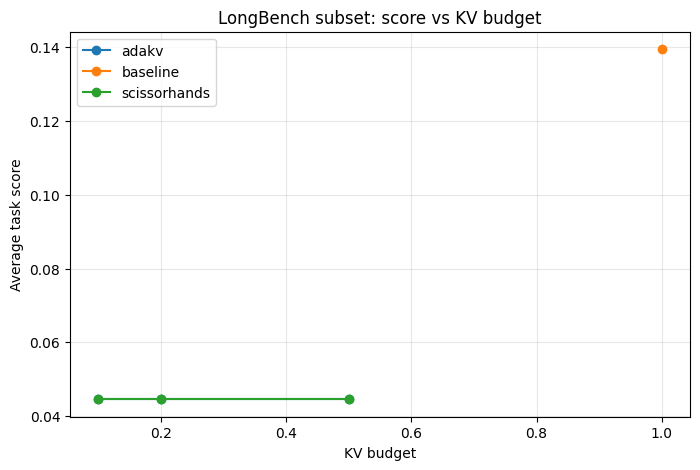

In [24]:
plt.figure(figsize=(8, 5))
for method in overall_df["method"].unique():
    sub = overall_df[overall_df["method"] == method].sort_values("kv_budget")
    plt.plot(sub["kv_budget"], sub["score_mean"], marker="o", label=method)

plt.xlabel("KV budget")
plt.ylabel("Average task score")
plt.title("LongBench subset: score vs KV budget")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 22. Plot throughput vs KV budget

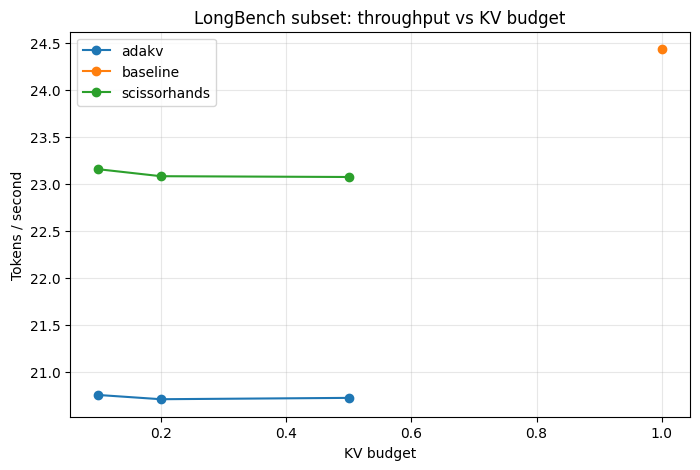

In [25]:
plt.figure(figsize=(8, 5))
for method in overall_df["method"].unique():
    sub = overall_df[overall_df["method"] == method].sort_values("kv_budget")
    plt.plot(sub["kv_budget"], sub["tps_mean"], marker="o", label=method)

plt.xlabel("KV budget")
plt.ylabel("Tokens / second")
plt.title("LongBench subset: throughput vs KV budget")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 23. Plot retained cache length vs KV budget

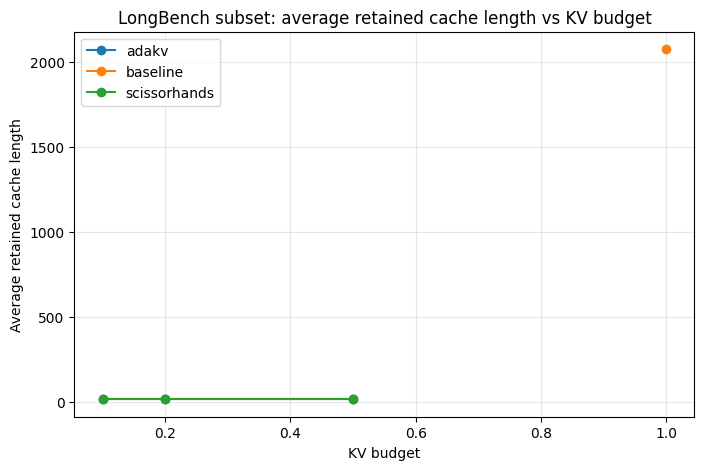

In [26]:
plt.figure(figsize=(8, 5))
for method in overall_df["method"].unique():
    sub = overall_df[overall_df["method"] == method].sort_values("kv_budget")
    plt.plot(sub["kv_budget"], sub["avg_cache_len_mean"], marker="o", label=method)

plt.xlabel("KV budget")
plt.ylabel("Average retained cache length")
plt.title("LongBench subset: average retained cache length vs KV budget")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 24. Task-wise table

In [27]:
pivot = summary_df.pivot_table(
    index=["task"],
    columns=["method", "kv_budget"],
    values="score_mean"
)
pivot


method              adakv                      baseline scissorhands  \
kv_budget             0.1       0.2       0.5       1.0          0.1   
task                                                                   
2wikimqa         0.034356  0.034356  0.034356  0.116212     0.034356   
gov_report       0.035926  0.035926  0.035926  0.062296     0.035926   
hotpotqa         0.016004  0.016004  0.016004  0.077969     0.016004   
multifieldqa_en  0.076013  0.076013  0.076013  0.326224     0.076013   
narrativeqa      0.041866  0.041866  0.041866  0.091453     0.041866   
qasper           0.063339  0.063339  0.063339  0.162471     0.063339   

method                               
kv_budget             0.2       0.5  
task                                 
2wikimqa         0.034356  0.034356  
gov_report       0.035926  0.035926  
hotpotqa         0.016004  0.016004  
multifieldqa_en  0.076013  0.076013  
narrativeqa      0.041866  0.041866  
qasper           0.063339  0.063339

## 25. Export JSON summary

In [29]:
json_path = OUTPUT_DIR / "overall_summary.json"
with open(json_path, "w") as f:
    json.dump(overall_df.to_dict(orient="records"), f, indent=2)
print("Saved:", json_path)


Saved: /content/kv_longbench_outputs/overall_summary.json


## 26. Notes for your report

### What this notebook implements
- **Baseline**: full KV cache, no compression
- **Scissorhands-style**: keeps recent tokens + top important historical tokens based on accumulated attention
- **AdaKV-style**: same importance mechanism, but with **adaptive per-layer budgets** based on attention concentration

### Why this still works as an analytical project
- You are implementing **two KV-cache compression ideas**
- You are controlling **cache budget**
- You are evaluating on a **LongBench** subset
- You are comparing **accuracy vs efficiency**

### Suggested final tables
1. Overall mean score / latency / tokens-per-second
2. Task-wise score table
3. Score vs KV budget plot
4. Throughput vs KV budget plot
5. Retained cache length vs KV budget plot

### Suggested discussion points
- Does aggressive compression (0.1) hurt QA more than summarization?
- Does AdaKV-style adaptive budgeting preserve quality better than Scissorhands-style at the same budget?
- How much throughput improvement do you get relative to the baseline?
